In [1]:
from pyexpat import features
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pickle
from tensorflow.keras.applications import ResNet152


In [2]:
model=Sequential()
model.add(Dense(512,activation='relu',input_dim=51200))
model.add(Dropout(0.3))
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
with open('features.h5', 'rb') as f:
    features=pickle.load(f)
with open('labels.h5', 'rb') as f:
    labels=pickle.load(f)


In [4]:
with open('features_test.h5', 'rb') as f:
    features_test=pickle.load(f)
with open('labels_test.h5', 'rb') as f:
    labels_test=pickle.load(f)

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    26,214,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,379,265 (100.63 MB)

 Trainable params: 26,379,265 (100.63 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history=model.fit(features,labels,epochs=30,batch_size=50,validation_data=(features_test,labels_test))

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.4900 - loss: 1.2724 - val_accuracy: 0.5057 - val_loss: 0.6949
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.4950 - loss: 0.7492 - val_accuracy: 0.5000 - val_loss: 0.6893
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.5155 - loss: 0.6989 - val_accuracy: 0.5314 - val_loss: 0.6887
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.5255 - loss: 0.6978 - val_accuracy: 0.5700 - val_loss: 0.6905
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.5440 - loss: 0.6903 - val_accuracy: 0.5943 - val_loss: 0.6887
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.5720 - loss: 0.6826 - val_accuracy: 0.6064 - val_loss: 0.6809
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.5205 - loss: 0.6913 - val_accuracy: 0.5000 - val_loss: 0.6842
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.5210 - loss: 0.6805 - val_accuracy: 0.5000 - 

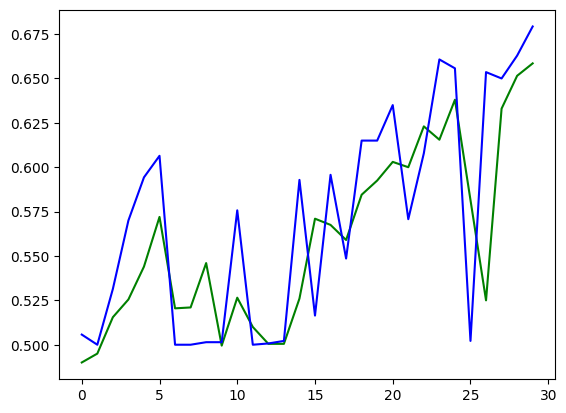

In [7]:
import matplotlib.pyplot as plt
epoch=range(30)
plt.plot(epoch,history.history['accuracy'] ,color='green')
plt.plot(epoch,history.history['val_accuracy'] ,color='blue')